>
> # Scenario analysis - Two-dimensional
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
import seaborn as sns
from scenarios import *
from scenarios_2D import *
from plot_func import *

In [2]:
# Enter variable and data type
# variable = {"name": "gini", "sym": "$G$", "int": False}
variable_1 = {"name": "comm-rate", "sym": "$\pi$", "int": False}
variable_2 = {"name": "fare", "sym": "$f_{\mathrm{km}}$", "int": False}
pos = [3,5]

In [3]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variable_1["name"]+'_'+variable_2["name"])
# dir_name = os.path.join(os.getcwd(),'input',variable["name"])
res, micro, params, drivers, requests, var_val = load_results_2d(dir_name, pos)

# Find variable values that have been tested
vals, scn = find_vals_2d(var_val, variable_1, variable_2)

# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res)

In [4]:
vals_1 = set([i.split('_', 1)[0] for i in vals])
vals_2 = set([i.split('_', 1)[1] for i in vals])

# abc_1 = set(map(int, [i.split('_', 1)[0] for i in vals]))
# abc_2 = set(map(int, [i.split('_', 1)[1] for i in vals]))

In [5]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl.head(20)

,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged
0,45,73.499486,23,1066.535735,45,True
1,35,75.785459,23,979.033385,35,True
2,36,76.285749,22,839.333848,36,True
3,33,105.222836,23,441.573822,33,True
4,45,86.476314,46,343.833687,46,True
5,27,92.318246,45,331.918643,45,True
6,39,91.922160,42,193.745603,42,True
7,29,97.182404,17,272.513148,29,True
8,31,97.135999,42,209.175090,42,True
9,34,93.415556,16,213.274760,34,True


In [6]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 3/3 for scenario 0.05_0.5
Sufficient number of replications: 3/1 for scenario 0.05_0.75
Sufficient number of replications: 3/1 for scenario 0.05_1.0
Sufficient number of replications: 3/1 for scenario 0.05_1.25
Sufficient number of replications: 3/1 for scenario 0.05_1.5
Sufficient number of replications: 3/1 for scenario 0.05_1.75
Sufficient number of replications: 3/1 for scenario 0.05_2.0
Sufficient number of replications: 3/2 for scenario 0.05_2.25
Sufficient number of replications: 3/1 for scenario 0.05_2.5
Sufficient number of replications: 3/2 for scenario 0.15_0.5
Sufficient number of replications: 3/1 for scenario 0.15_0.75
Sufficient number of replications: 3/1 for scenario 0.15_1.0
Sufficient number of replications: 3/2 for scenario 0.15_1.25
Sufficient number of replications: 3/1 for scenario 0.15_1.5
Sufficient number of replications: 3/1 for scenario 0.15_1.75
Sufficient number of replications: 3/1 for scenario 0.15_2.0
Sufficient number

In [7]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [8]:
eql_scn.dem.head(40)

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,...,vot_inf,vot_req,std_perc_wait,std_exp_wait,std_corr_wait,std_perc_wait_req,cons_surplus,pickup_time,match_time,corr_match_time
scenario,,,,,,,,,,,,,,,,,,,,,
0.05_0.5,72519.000000,3772.666667,0.890199,3358.400000,381.392049,536.986404,701.258012,601.964758,51861.666667,10747.400000,...,10.233058,11.316439,321.097082,270.976621,510.129836,276.132626,1783.574643,253.823701,127.568348,NaN
0.05_0.75,61695.333333,4804.800000,0.996026,4785.666667,171.673413,178.135545,231.577096,197.372126,42882.533333,9092.933333,...,11.364263,15.656719,167.649506,185.155966,209.976777,136.957727,4551.326699,164.750949,6.922463,NaN
0.05_1.0,46793.000000,3695.000000,1.000000,3695.000000,136.560960,136.560960,155.586870,136.783494,32285.800000,7337.733333,...,13.182318,17.953284,115.245578,156.605276,156.605276,95.660923,3608.533834,137.323915,-0.762955,NaN
0.05_1.25,33426.000000,2599.866667,1.000000,2599.866667,112.798996,112.798996,131.287656,119.169765,22828.333333,5703.266667,...,15.365395,20.422368,89.468528,123.848586,123.848586,76.893155,2515.672876,114.483019,-1.684022,NaN
0.05_1.5,23290.666667,1770.400000,1.000000,1770.400000,107.029226,107.029226,120.860962,110.791348,15791.800000,4277.466667,...,17.730575,23.249750,73.112333,111.386222,111.386222,63.331166,1712.271445,109.150595,-2.121369,NaN
0.05_1.75,16084.333333,1166.733333,1.000000,1166.733333,105.751685,105.751685,122.763953,112.534009,10849.933333,3158.666667,...,20.210243,25.955284,69.848236,104.464960,104.464960,59.605159,1093.713478,108.297537,-2.545853,NaN
0.05_2.0,11124.000000,790.000000,1.000000,790.000000,107.688281,107.688281,124.262459,112.248349,7432.066667,2324.733333,...,22.745133,28.657936,70.140259,100.907508,100.907508,56.380662,739.793962,110.672548,-2.984267,NaN
0.05_2.25,7714.333333,532.000000,1.000000,532.000000,114.185515,114.185515,131.015607,117.361137,5143.533333,1669.666667,...,25.318766,31.682976,67.329315,101.148013,101.148013,54.153344,485.549807,117.601227,-3.415712,NaN
0.05_2.5,5409.666667,343.400000,1.000000,343.400000,129.239835,129.239835,145.305597,131.825671,3592.000000,1231.800000,...,27.922964,34.606550,69.795836,110.958248,110.958248,58.910190,300.308714,133.058854,-3.819019,NaN


In [42]:
eql_scn.sup.loc['0.55_0.5']

inform                2500.000000
regist                  61.066667
rejected_reg             0.000000
particip                 0.000000
reject_particip          0.000000
mean_perc_inc            2.757764
mean_perc_inc_ptcp            NaN
mean_perc_inc_reg        3.048106
mean_exp_inc                  NaN
rel_perc_inc             0.019636
rel_perc_inc_reg         0.022705
rel_perc_inc_ptcp             NaN
std_perc_inc             2.563382
std_exp_inc                   NaN
std_perc_inc_reg         1.064901
std_perc_inc_ptcp             NaN
res_wage_inf           200.493743
res_wage_reg           218.964917
res_wage_ptcp                 NaN
new_regist               5.200000
deregist                 4.600000
driver_surplus       -1221.333333
mean_rev                      NaN
mean_op_costs                 NaN
ivt_costs                     NaN
dh_costs                      NaN
mean_dh_dist                  NaN
mean_dh_time                  NaN
drive_time                    NaN
not_idle_time 

In [10]:
eql_scn.plf.head(40)

,plat_profit
0.05_0.5,858.956697
0.05_0.75,1436.971955
0.05_1.0,1342.822450
0.05_1.25,1101.952463
0.05_1.5,848.225210
0.05_1.75,621.065341
0.05_2.0,458.969933
0.05_2.25,338.667668
0.05_2.5,232.707725
0.15_0.5,1950.837315


In [11]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [12]:
# Add scenario values as columns to df
eql_scn.sup = add_scn_vals(eql_scn.sup, variable_1, variable_2)
eql_scn.dem = add_scn_vals(eql_scn.dem, variable_1, variable_2)
eql_scn.plf = add_scn_vals(eql_scn.plf, variable_1, variable_2)

# eql_scn.plf[variable_1["name"]] = eql_scn.plf.index.str.split('_').str.get(0).astype(int)
# eql_scn.plf[variable_2["name"]] = eql_scn.plf.index.str.split('_').str.get(1).astype(int)
# eql_scn.index.name = 'scenario'

# # Add missing scenarios to df as nan's
# scn_names = []
# for val_1 in vals_1:
#     for val_2 in vals_2:
#         scn_name = str(val_1)+'_'+str(val_2)
#         scn_names.append(scn_name)
#         if scn_name not in eql_scn.plf.index:
#             eql_scn.plf = eql_scn.plf.append(pd.Series(data={'profit': np.nan,'nP': int(val_1), 'nV': int(val_2)}, name = scn_name), ignore_index=False)

# eql_scn.plf = eql_scn.plf.sort_values(["nP", "nV"])
# eql_scn.plf = eql_scn.plf.set_index(['nP','nV'])
# eql_scn.plf = eql_scn.plf.unstack(level=-1)
# eql_scn.plf.style.background_gradient(axis=None)

In [13]:
# # eql_scn.plf = eql_scn.plf.pivot(index='nP', columns='nV', values='profit')
# # sns.heatmap(data)
# sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values='profit'))
# plt.show()

In [14]:
# Find societal value
eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])
eql_scn.soc = add_scn_vals(eql_scn.soc, variable_1, variable_2)

In [15]:
# Change commission to percentage
eql_scn.sup['comm-rate'] = eql_scn.sup['comm-rate'] * 100
eql_scn.dem['comm-rate'] = eql_scn.dem['comm-rate'] * 100
eql_scn.plf['comm-rate'] = eql_scn.plf['comm-rate'] * 100
eql_scn.soc['comm-rate'] = eql_scn.soc['comm-rate'] * 100

In [16]:
eql_scn.sup['comm-rate'] = eql_scn.sup['comm-rate'].astype(int)
eql_scn.dem['comm-rate'] = eql_scn.dem['comm-rate'].astype(int)
eql_scn.plf['comm-rate'] = eql_scn.plf['comm-rate'].astype(int)
eql_scn.soc['comm-rate'] = eql_scn.soc['comm-rate'].astype(int)

C:\Users\arjanderuijter\Anaconda3\envs\MS_venv\lib\site-packages\seaborn\matrix.py:204: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\arjanderuijter\Anaconda3\envs\MS_venv\lib\site-packages\seaborn\matrix.py:209: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


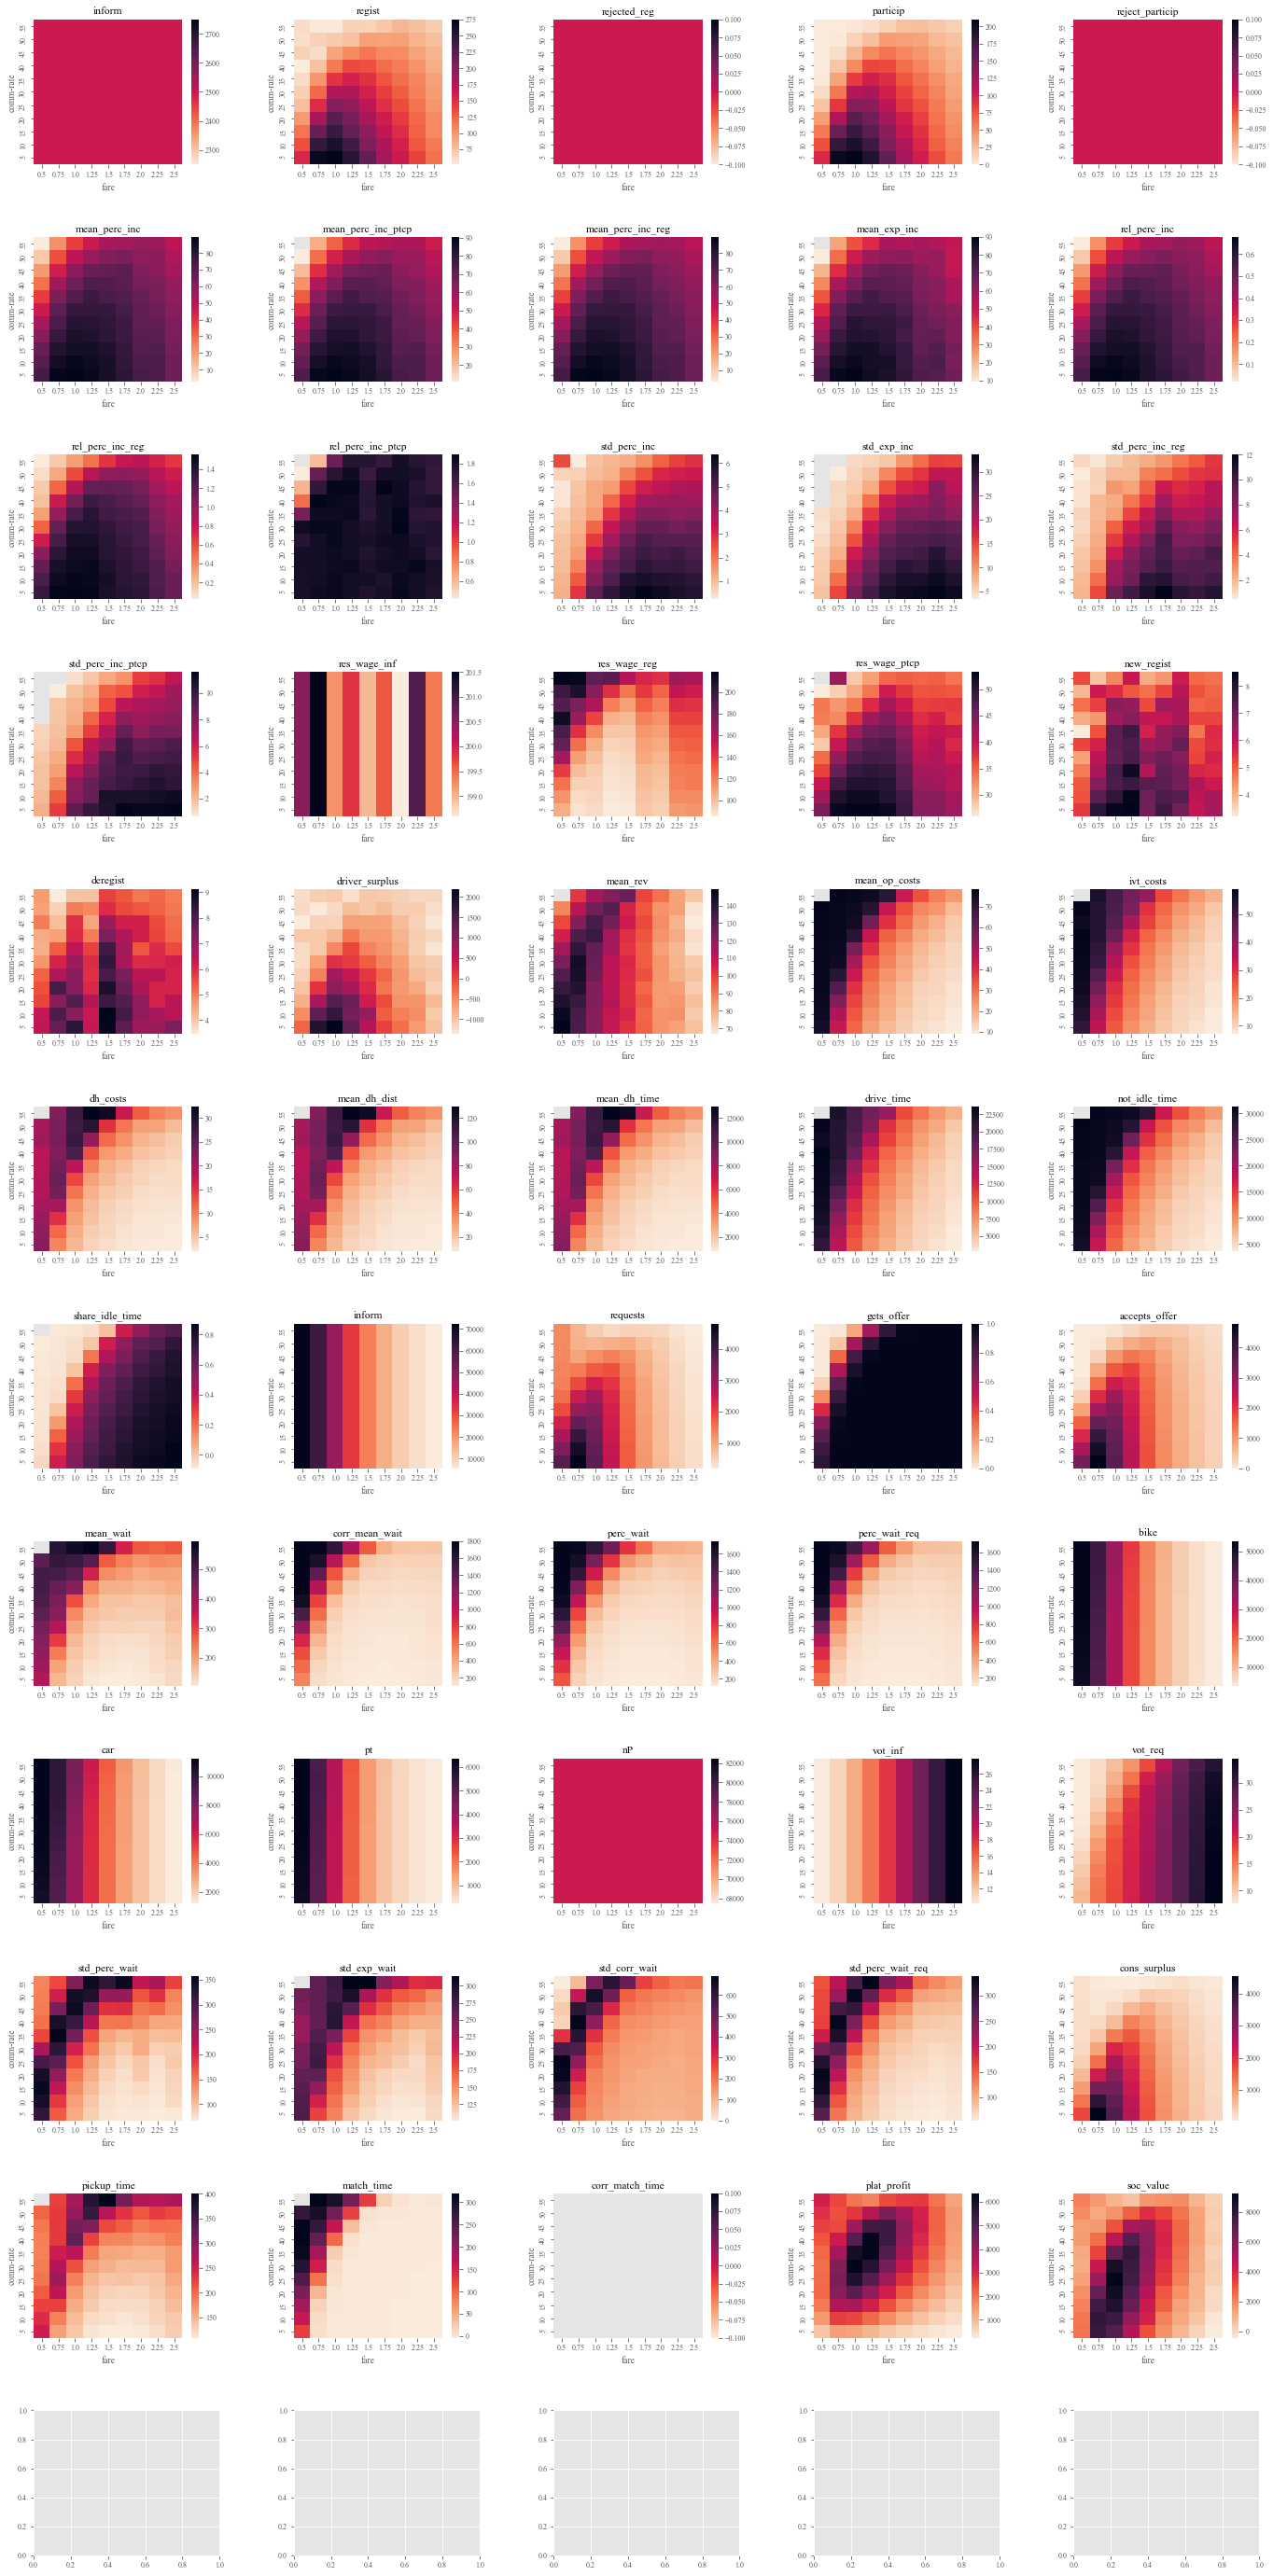

In [17]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(12, 5, figsize = [24,50])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

i = 0
j = 0
for kpi in kpis_sup:
    axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 4:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 4:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 4:
        i = 0
        j += 1
        
axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values = 'soc_value'), ax=axes[j,i], cmap=cmap)
axes[j, i].set_title('soc_value')
axes[j, i].invert_yaxis()
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'heat_maps.jpg'),dpi=300,bbox_inches='tight')

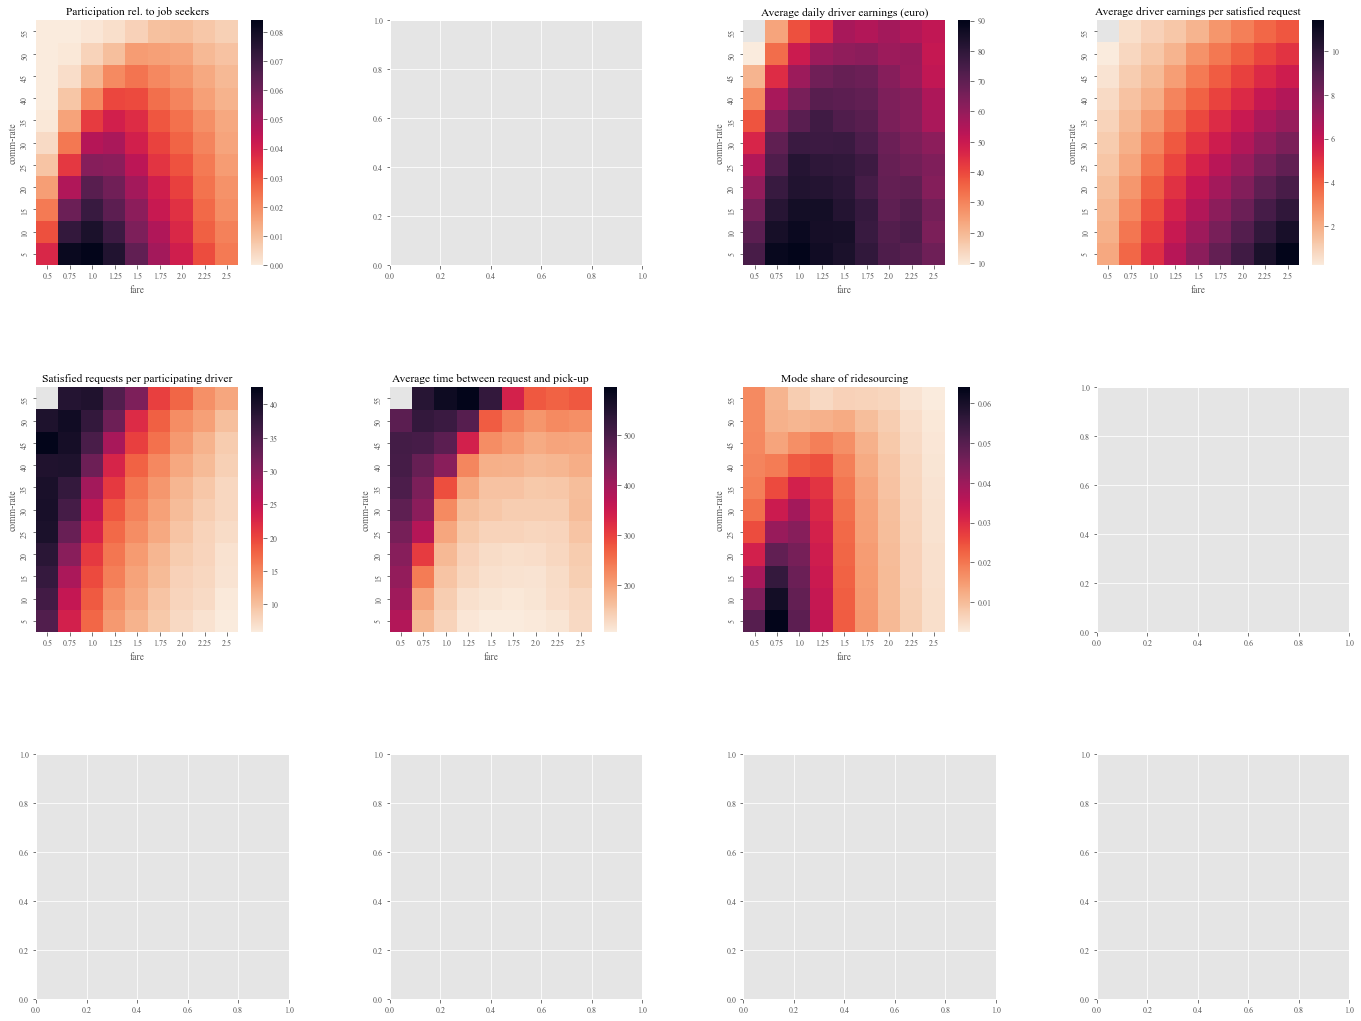

In [18]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(3, 4, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc[variable_1['name']] = eql_scn.sup[variable_1['name']]
res_proc[variable_2['name']] = eql_scn.sup[variable_2['name']]

res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='part_inf'), ax = axes[0,0], cmap=cmap)
axes[0,0].set_title('Participation rel. to job seekers')
axes[0,0].invert_yaxis()
# axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.nP
axes[1,2] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='part_inf'), ax = axes[1,2], cmap=cmap)
axes[1,2].set_title('Mode share of ridesourcing')
axes[1,2].invert_yaxis()
# axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
axes[0,2] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='exp_inc'), ax = axes[0,2], cmap=cmap)
axes[0,2].set_title('Average daily driver earnings (€)')
axes[0,2].invert_yaxis()

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[0,3] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='earn_req_sat'), ax = axes[0,3], cmap=cmap)
axes[0,3].set_title('Average driver earnings per satisfied request')
axes[0,3].invert_yaxis()


res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[1,0] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='serv_req_part'), ax = axes[1,0], cmap=cmap)
axes[1,0].set_title('Satisfied requests per participating driver')
axes[1,0].invert_yaxis()

res_proc['wait_time'] = eql_scn.dem.mean_wait
axes[1,1] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='wait_time'), ax = axes[1,1], cmap=cmap)
axes[1,1].set_title('Average time between request and pick-up')
axes[1,1].invert_yaxis()

# res_proc = pd.DataFrame(index = eql_scn.sup.index)
# res_proc['nP'] = eql_scn.sup.nP
# res_proc['nV'] = eql_scn.sup.nV

# res_proc['req_part'] = eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_part'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Incoming requests per participating driver')
# axes[0,0].invert_yaxis()

# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Satisfied requests per participating driver')
# axes[0,3].invert_yaxis()

# res_proc['earn_req'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / eql_scn.dem.requests
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average earnings per request')
# axes[0,1].invert_yaxis()

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Average earnings per satisfied request')
# axes[1,0].invert_yaxis()

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average waiting time for pick-up')
# axes[0,2].invert_yaxis()

# res_proc['part_trav'] = eql_scn.sup.particip / eql_scn.dem.inform
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_trav'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Participating drivers per traveller')
# axes[1,1].invert_yaxis()

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Participation rel. to job seekers')
# axes[1,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,3], cmap=cmap)
# axes[1,3].set_title('Mode share of ridesourcing')
# axes[1,3].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['reg_inf'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='reg_inf'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Share of job seekers registered with platform')
# axes[2,0].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))

# i = 0
# j = 0
# for kpi in kpis_sup:
#     axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_dem:
#     axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_plf:
#     axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1
        
# axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i])
# axes[j, i].set_title('soc_value')
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'heat_maps_select.jpg'),dpi=300,bbox_inches='tight')

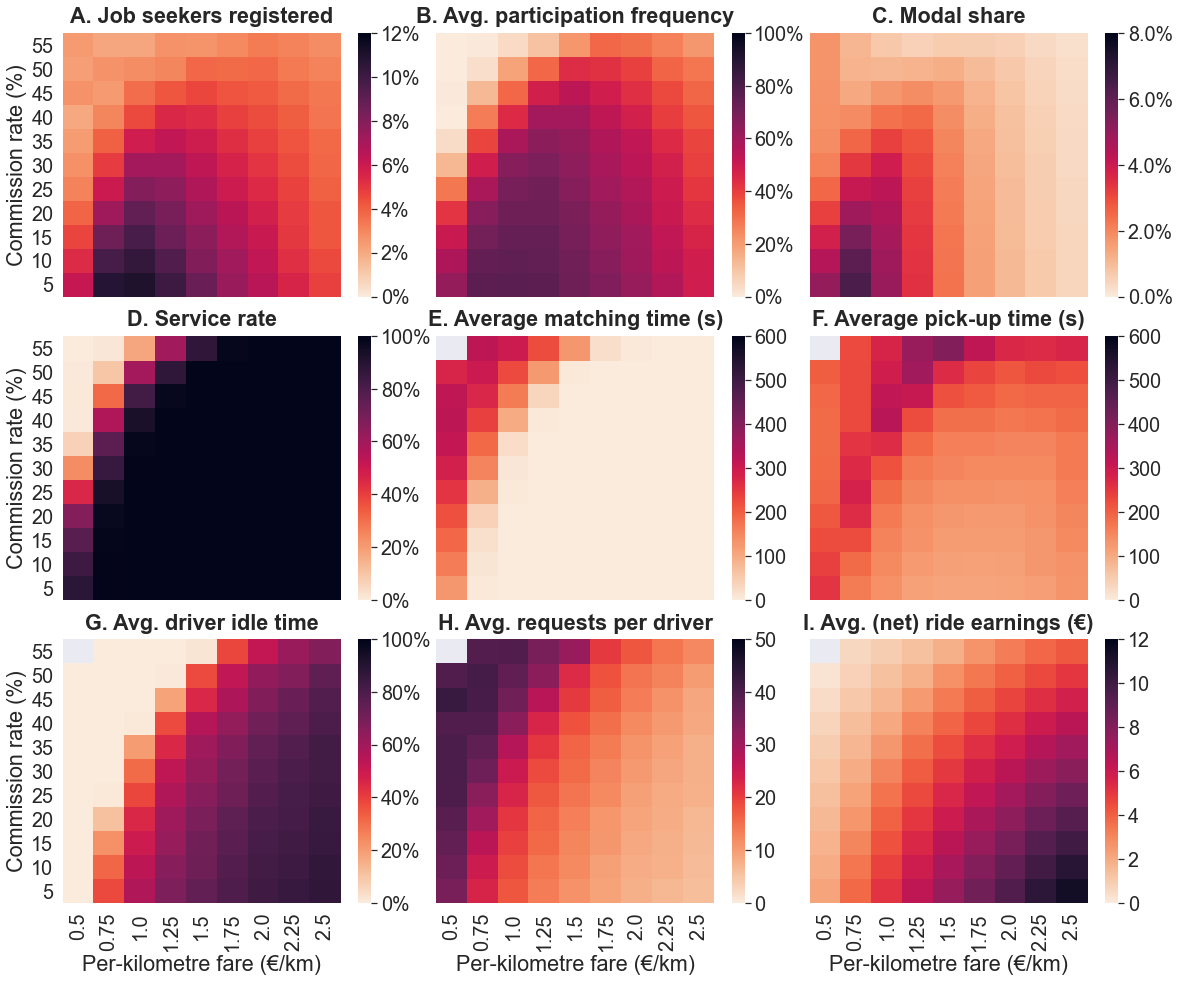

In [43]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(3, 3, figsize = [20,16], sharex=True, sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.15, wspace=0.075, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['fare'] = eql_scn.sup[variable_1['name']]
res_proc['comm-rate'] = eql_scn.sup[variable_2['name']]

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[2,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,3], cmap=cmap)
# axes[2,3].set_title('Participation rel. to job seekers')
# axes[2,3].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.sup.particip / res_proc.nP
# axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,2], cmap=cmap)
# axes[2,2].set_title('Participation rel. to travellers')
# axes[2,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['mode_share'] = eql_scn.dem.requests / eql_scn.dem.nP # eql_scn.dem.inform
axes[0,2] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='mode_share'), ax = axes[0,2], cmap=cmap, vmin=0, vmax=0.08)
cbar = axes[0,2].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 1))
axes[0,2].set_title('C. Modal share', fontweight="bold", pad=10)
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[0,2].set_ylabel('Commission rate (%)')
axes[0,2].xaxis.label.set_visible(False)
axes[0,2].yaxis.label.set_visible(False)
# axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
# axes[0,2] = sns.heatmap(res_proc.pivot(index='fare', columns='nV', values='exp_inc'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average daily driver earnings (euro)')
# axes[0,2].invert_yaxis()

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[2,2] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='earn_req_sat'), ax = axes[2,2], cmap=cmap, vmin=0, vmax=12)
axes[2,2].set_title('I. Avg. (net) ride earnings (\u20ac)', fontweight="bold", pad=10)
axes[2,2].invert_yaxis()
axes[2,2].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[2,2].set_ylabel('Commission rate (%)')
axes[2,2].yaxis.label.set_visible(False)

res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[2,1] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='serv_req_part'), ax = axes[2,1], cmap=cmap, vmin=0, vmax=50)
axes[2,1].set_title('H. Avg. requests per driver', fontweight="bold", pad=10)
axes[2,1].invert_yaxis()
axes[2,1].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[2,1].set_ylabel('Commission rate (%)')
axes[2,1].yaxis.label.set_visible(False)

res_proc['idle_time'] = eql_scn.sup.share_idle_time
axes[2,0] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='idle_time'), ax = axes[2,0], cmap=cmap, vmin=0, vmax=1)
axes[2,0].set_title('G. Avg. driver idle time', fontweight="bold", pad=10)
cbar = axes[2,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[2,0].invert_yaxis()
axes[2,0].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[2,0].set_ylabel('Commission rate (%)')
axes[2,0].set_yticklabels(axes[2,0].get_yticklabels(), rotation = 0)
# axes[2,0].yaxis.label.set_visible(False)

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[1,1] = sns.heatmap(res_proc.pivot(index='fare', columns='nV', values='wait_time'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Average time between request and pick-up')
# axes[1,1].invert_yaxis()

res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='regist'), ax = axes[0,0], cmap=cmap, vmin=0, vmax=0.12)
cbar = axes[0,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,0].set_title('A. Job seekers registered', fontweight="bold", pad=10)
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[0,0].set_ylabel('Commission rate (%)')
axes[0,0].xaxis.label.set_visible(False)
axes[0,0].set_yticklabels(axes[0,0].get_yticklabels(), rotation = 0)

res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
axes[0,1] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='ptcp_prob'), ax = axes[0,1], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,1].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,1].set_title('B. Avg. participation frequency', fontweight="bold", pad=10)
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[0,1].set_ylabel('Commission rate (%)')
axes[0,1].xaxis.label.set_visible(False)
axes[0,1].yaxis.label.set_visible(False)

res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
axes[1,0] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='match_rate'), ax = axes[1,0], cmap=cmap, vmin=0, vmax=1)
cbar = axes[1,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[1,0].set_title('D. Service rate', fontweight="bold", pad=10)
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[1,0].set_ylabel('Commission rate (%)')
axes[1,0].xaxis.label.set_visible(False)
axes[1,0].set_yticklabels(axes[1,0].get_yticklabels(), rotation = 0)
# axes[1,0].yaxis.label.set_visible(False)

res_proc['match_time'] = eql_scn.dem.match_time.copy()
axes[1,1] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='match_time'), ax = axes[1,1], cmap=cmap, vmin=0, vmax=600)
axes[1,1].set_title('E. Average matching time (s)', fontweight="bold", pad=10)
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[1,1].set_ylabel('Commission rate (%)')
axes[1,1].xaxis.label.set_visible(False)
axes[1,1].yaxis.label.set_visible(False)

res_proc['pickup_time'] = eql_scn.dem.pickup_time.copy()
axes[1,2] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='pickup_time'), ax = axes[1,2], cmap=cmap, vmin=0, vmax=600)
axes[1,2].set_title('F. Average pick-up time (s)', fontweight="bold", pad=10)
axes[1,2].invert_yaxis()
axes[1,2].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[1,2].set_ylabel('Commission rate (%)')
axes[1,2].yaxis.label.set_visible(False)
axes[1,2].xaxis.label.set_visible(False)

# res_proc['req_per_driver'] = eql_scn.sup.particip / eql_scn.dem.requests
# axes[2,0] = sns.heatmap(res_proc.pivot(index='fare', columns='nV', values='req_per_driver'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Participating drivers per request')
# axes[2,0].invert_yaxis()
# res_proc = pd.DataFrame(index = eql_scn.sup.index)
# res_proc['nP'] = eql_scn.sup.nP
# res_proc['nV'] = eql_scn.sup.nV

# res_proc['req_part'] = eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_part'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Incoming requests per participating driver')
# axes[0,0].invert_yaxis()

# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Satisfied requests per participating driver')
# axes[0,3].invert_yaxis()

# res_proc['earn_req'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / eql_scn.dem.requests
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average earnings per request')
# axes[0,1].invert_yaxis()

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Average earnings per satisfied request')
# axes[1,0].invert_yaxis()

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average waiting time for pick-up')
# axes[0,2].invert_yaxis()

# res_proc['part_trav'] = eql_scn.sup.particip / eql_scn.dem.inform
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_trav'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Participating drivers per traveller')
# axes[1,1].invert_yaxis()

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Participation rel. to job seekers')
# axes[1,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,3], cmap=cmap)
# axes[1,3].set_title('Mode share of ridesourcing')
# axes[1,3].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['reg_inf'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='reg_inf'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Share of job seekers registered with platform')
# axes[2,0].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))

# i = 0
# j = 0
# for kpi in kpis_sup:
#     axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_dem:
#     axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_plf:
#     axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1
        
# axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i])
# axes[j, i].set_title('soc_value')
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()

# from matplotlib.patches import Rectangle, Polygon, Patch
# array = np.array([[0,0],[7,0],[7,1],[2,1],[2,2],[0,2]])
# axes[1,0].add_patch(Polygon(array, closed=True, linewidth=-5, ec='y', fill=False))

# legend_elements = [Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient strategy')]

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'pricing_heat_main.jpg'),dpi=300,bbox_inches='tight')

In [94]:
eql_scn.dem['gets_offer'].loc['0.3_1.0']
# eql_scn.plf['plat_profit'].loc['0.3_1.0']
# (eql_scn.dem.requests / eql_scn.dem.nP)['0.4_1.25']
# eql_scn.plf['plat_profit'].loc['0.4_1.25'] / eql_scn.plf['plat_profit'].loc['0.3_1.0']
# eql_scn.dem['gets_offer'].loc['0.4_1.25']
eql_scn.dem['requests'].loc['0.35_1.25'] / eql_scn.dem['requests'].loc['0.3_1.0']

0.7261837367813226

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

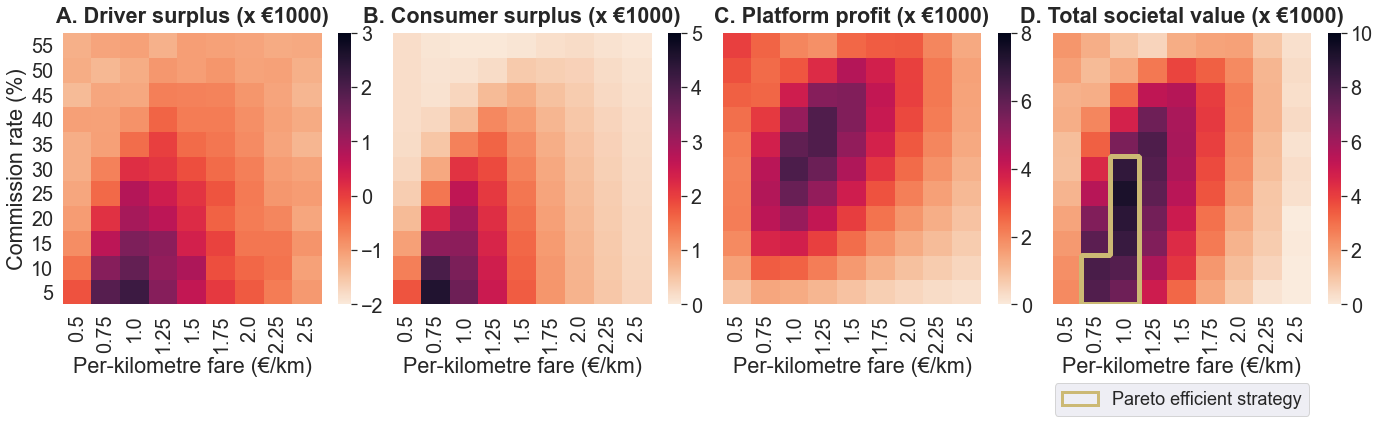

In [68]:
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,5],sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.55, wspace=0.02, left=.12, right=.88)

axes[0] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values='driver_surplus')/1000, ax = axes[0], cmap=cmap, vmin=-2, vmax=3)
axes[0].set_title('A. Driver surplus (x \u20ac1000)',fontweight="bold",pad=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[0].set_ylabel('Commission rate (%)')
# axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(10))
# axes[0].set_xticklabels(axes[0].get_xmajorticklabels(), fontsize = 14)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation = 0)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 90)

axes[1] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values='cons_surplus')/1000, ax = axes[1], cmap=cmap, vmin=0, vmax=5)
axes[1].set_title('B. Consumer surplus (x \u20ac1000)',fontweight="bold",pad=10)
axes[1].invert_yaxis()
axes[1].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[1].set_ylabel('Commission rate (%)')
# axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation = 0)
axes[1].yaxis.label.set_visible(False)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation = 90)

axes[2] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values='plat_profit')/1000, ax = axes[2], cmap=cmap, vmin=0, vmax=8)
axes[2].set_title('C. Platform profit (x \u20ac1000)',fontweight="bold",pad=10)
axes[2].invert_yaxis()
axes[2].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[2].set_ylabel('Commission rate (%)')
# axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation = 0)
axes[2].yaxis.label.set_visible(False)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation = 90)

axes[3] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='soc_value')/1000, ax = axes[3], cmap=cmap, vmin=0, vmax=10)
axes[3].set_title('D. Total societal value (x \u20ac1000)',fontweight="bold",pad=10)
axes[3].invert_yaxis()
axes[3].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[3].set_ylabel('Commission rate (%)')
axes[3].yaxis.label.set_visible(False)
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation = 90)
# axes[3].set_yticklabels(axes[3].get_yticklabels(), rotation = 0)
from matplotlib.patches import Rectangle, Polygon
# axes[3].add_patch(Rectangle((1, 5), 5, 1, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 0), 1, 4, hatch='.', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((3, 0), 3, 6, hatch='\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((1, 4), 1, 1, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 0), 1, 4, hatch='\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 4), 1, 2, hatch='+', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 4), 1, 1, hatch='O', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((1, 0), 1, 4, linewidth=-5, ec='y', fill=False))

# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor="None", hatch='..', edgecolor='k',
#                          label='Pareto inefficient: increase per-kilometre fare'),
#                    Patch(facecolor="None", hatch='\\\\', edgecolor='k',
#                          label='Pareto inefficient: decrease per-kilometre fare'),
#                    Patch(facecolor="None", hatch='///', edgecolor='k', 
#                          label='Pareto inefficient: decrease commission rate'),
#                    Patch(facecolor="None", hatch='++', edgecolor='k', 
#                          label='Pareto inefficient: increase per-kilometre fare and decrease commission'),
#                    Patch(facecolor="None", hatch='OO', edgecolor='k', 
#                          label='Pareto inefficient: decrease per-kilometre fare and commission'),
#                    Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient')]
# axes[3].legend(handles=legend_elements, loc='center')

# axes[3].add_patch(Rectangle((0, 0), 1, 5, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((3, 0), 8, 5, hatch='\\\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 3), 11, 2, hatch='--', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 0), 1, 1, linewidth=-5, ec='y', fill=False))
# axes[3].add_patch(Rectangle((1, 0), 1, 1, linewidth=-5, ec='y', fill=False))
# axes[3].add_patch(Rectangle((1, 1), 1, 1, linewidth=-5, ec='y', fill=False))
# axes[3].add_patch(Rectangle((1, 2), 1, 1, linewidth=-5, ec='y', fill=False))
# axes[3].add_patch(Rectangle((1, 3), 1, 1, linewidth=-5, ec='y', fill=False))

# axes[3].add_patch(Rectangle((1, 4), 1, 1, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 0), 1, 4, hatch='\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 4), 1, 2, hatch='+', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 4), 1, 1, hatch='O', linewidth=0, ec='k', fill=False))

array = np.array([[1,0],[3,0],[3,6],[2,6],[2,2],[1,2]])
axes[3].add_patch(Polygon(array, closed=True, linewidth=-5, ec='y', fill=False))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="None", linewidth=3, edgecolor='y', 
                         label='Pareto efficient strategy')]
#                    Patch(facecolor="None", hatch='///', edgecolor='k',
#                          label='Per-kilometre fare too low'),
#                    Patch(facecolor="None", hatch='\\\\\\', edgecolor='k',
#                          label='Per-kilometre fare too high'),
#                    Patch(facecolor="None", hatch='---', edgecolor='k', 
#                          label='Commission rate too high')]
# axes[3].legend(handles=legend_elements,fontsize=18, loc='center', bbox_to_anchor=(0.5, -0.55))
axes[3].legend(handles=legend_elements,fontsize=18, loc='center', bbox_to_anchor=(0.5, -0.35))

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'pricing_soc.jpg'),dpi=300,bbox_inches='tight')

Text(174.85999999999999, 0.5, 'Commission rate')

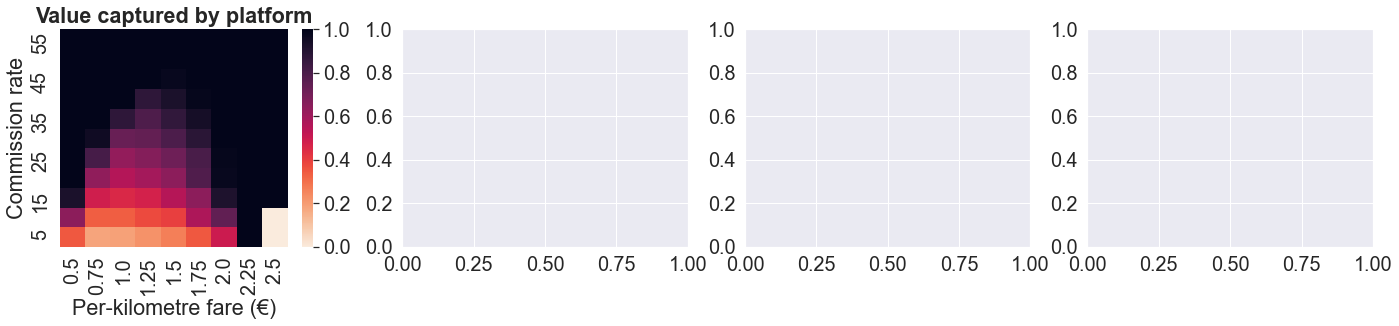

In [21]:
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,4])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.2, left=.12, right=.88)

eql_scn.soc['rel_profit'] = eql_scn.plf.plat_profit / eql_scn.soc.soc_value
axes[0] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='rel_profit'), ax = axes[0], cmap=cmap, vmin=0, vmax=1)
axes[0].set_title('Value captured by platform',fontweight="bold")
axes[0].invert_yaxis()
axes[0].set_xlabel('Per-kilometre fare (\u20ac)')
axes[0].set_ylabel('Commission rate')
# axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(10))
# axes[0].set_xticklabels(axes[0].get_xmajorticklabels(), fontsize = 14)

In [96]:
res_proc.to_csv('res_proc.csv')

In [97]:
eql_scn.sup.to_csv('eql_scn_sup.csv')
eql_scn.dem.to_csv('eql_scn_dem.csv')
eql_scn.plf.to_csv('eql_scn_plf.csv')

In [22]:
# eql_scn.sup[eql_scn.sup['fare']==1.0]
eql_scn.plf[eql_scn.plf['fare']==1.25]

,plat_profit,comm-rate,fare
scenario,,,
0.05_1.25,1101.952463,5,1.25
0.15_1.25,3187.839338,15,1.25
0.1_1.25,2166.339250,10,1.25
0.25_1.25,5051.849875,25,1.25
0.2_1.25,4160.195350,20,1.25
0.35_1.25,6325.119704,35,1.25
0.3_1.25,5796.594475,30,1.25
0.45_1.25,5308.320412,45,1.25
0.4_1.25,6316.307333,40,1.25


In [99]:
res.sup[0]

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,driver_surplus,mean_rev,mean_op_costs,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time
day,,,,,,,,,,,,,,,,,,,,,
0,205,34,0,18,0,212.084274,208.897895,235.343355,60.796528,1.000000,...,-3345.824616,136.902758,76.106231,48.137417,27.968814,111.875256,11187.525556,19254.966667,30442.492222,-0.057031
1,220,35,0,11,0,176.494748,279.049102,215.492944,73.856591,0.871925,...,-2974.207672,150.401020,76.544430,52.362977,24.181452,96.725809,9672.580909,20945.190909,30617.771818,-0.063117
2,242,35,0,8,0,150.644879,131.852297,202.595129,76.366312,0.796231,...,-1167.878208,153.631209,77.264897,53.764781,23.500116,94.000463,9400.046250,21505.912500,30905.958750,-0.073124
3,259,35,0,6,0,134.892115,128.148367,200.058627,76.533167,0.749339,...,-1046.588797,153.785842,77.252675,53.689917,23.562758,94.251033,9425.103333,21475.966667,30901.070000,-0.072954
4,287,38,0,5,0,121.451834,124.664925,192.746642,80.298350,0.714641,...,-990.060658,158.179370,77.881020,54.602300,23.278720,93.114880,9311.488000,21840.920000,31152.408000,-0.081681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2500,151,0,95,0,73.857532,74.018194,74.232606,74.063568,0.551676,...,-259.155127,148.343500,74.279932,52.275526,22.004405,88.017621,8801.762105,20910.210526,29711.972632,-0.031666
196,2500,155,0,101,0,73.893300,74.127667,74.226429,72.726181,0.551944,...,-475.852633,144.072687,71.346507,50.609908,20.736598,82.946393,8294.639307,20243.963366,28538.602673,0.009076
197,2500,148,0,91,0,73.671031,73.877945,74.083562,76.182978,0.550237,...,-118.973631,152.071093,75.888115,53.655549,22.232566,88.930264,8893.026374,21462.219780,30355.246154,-0.054002


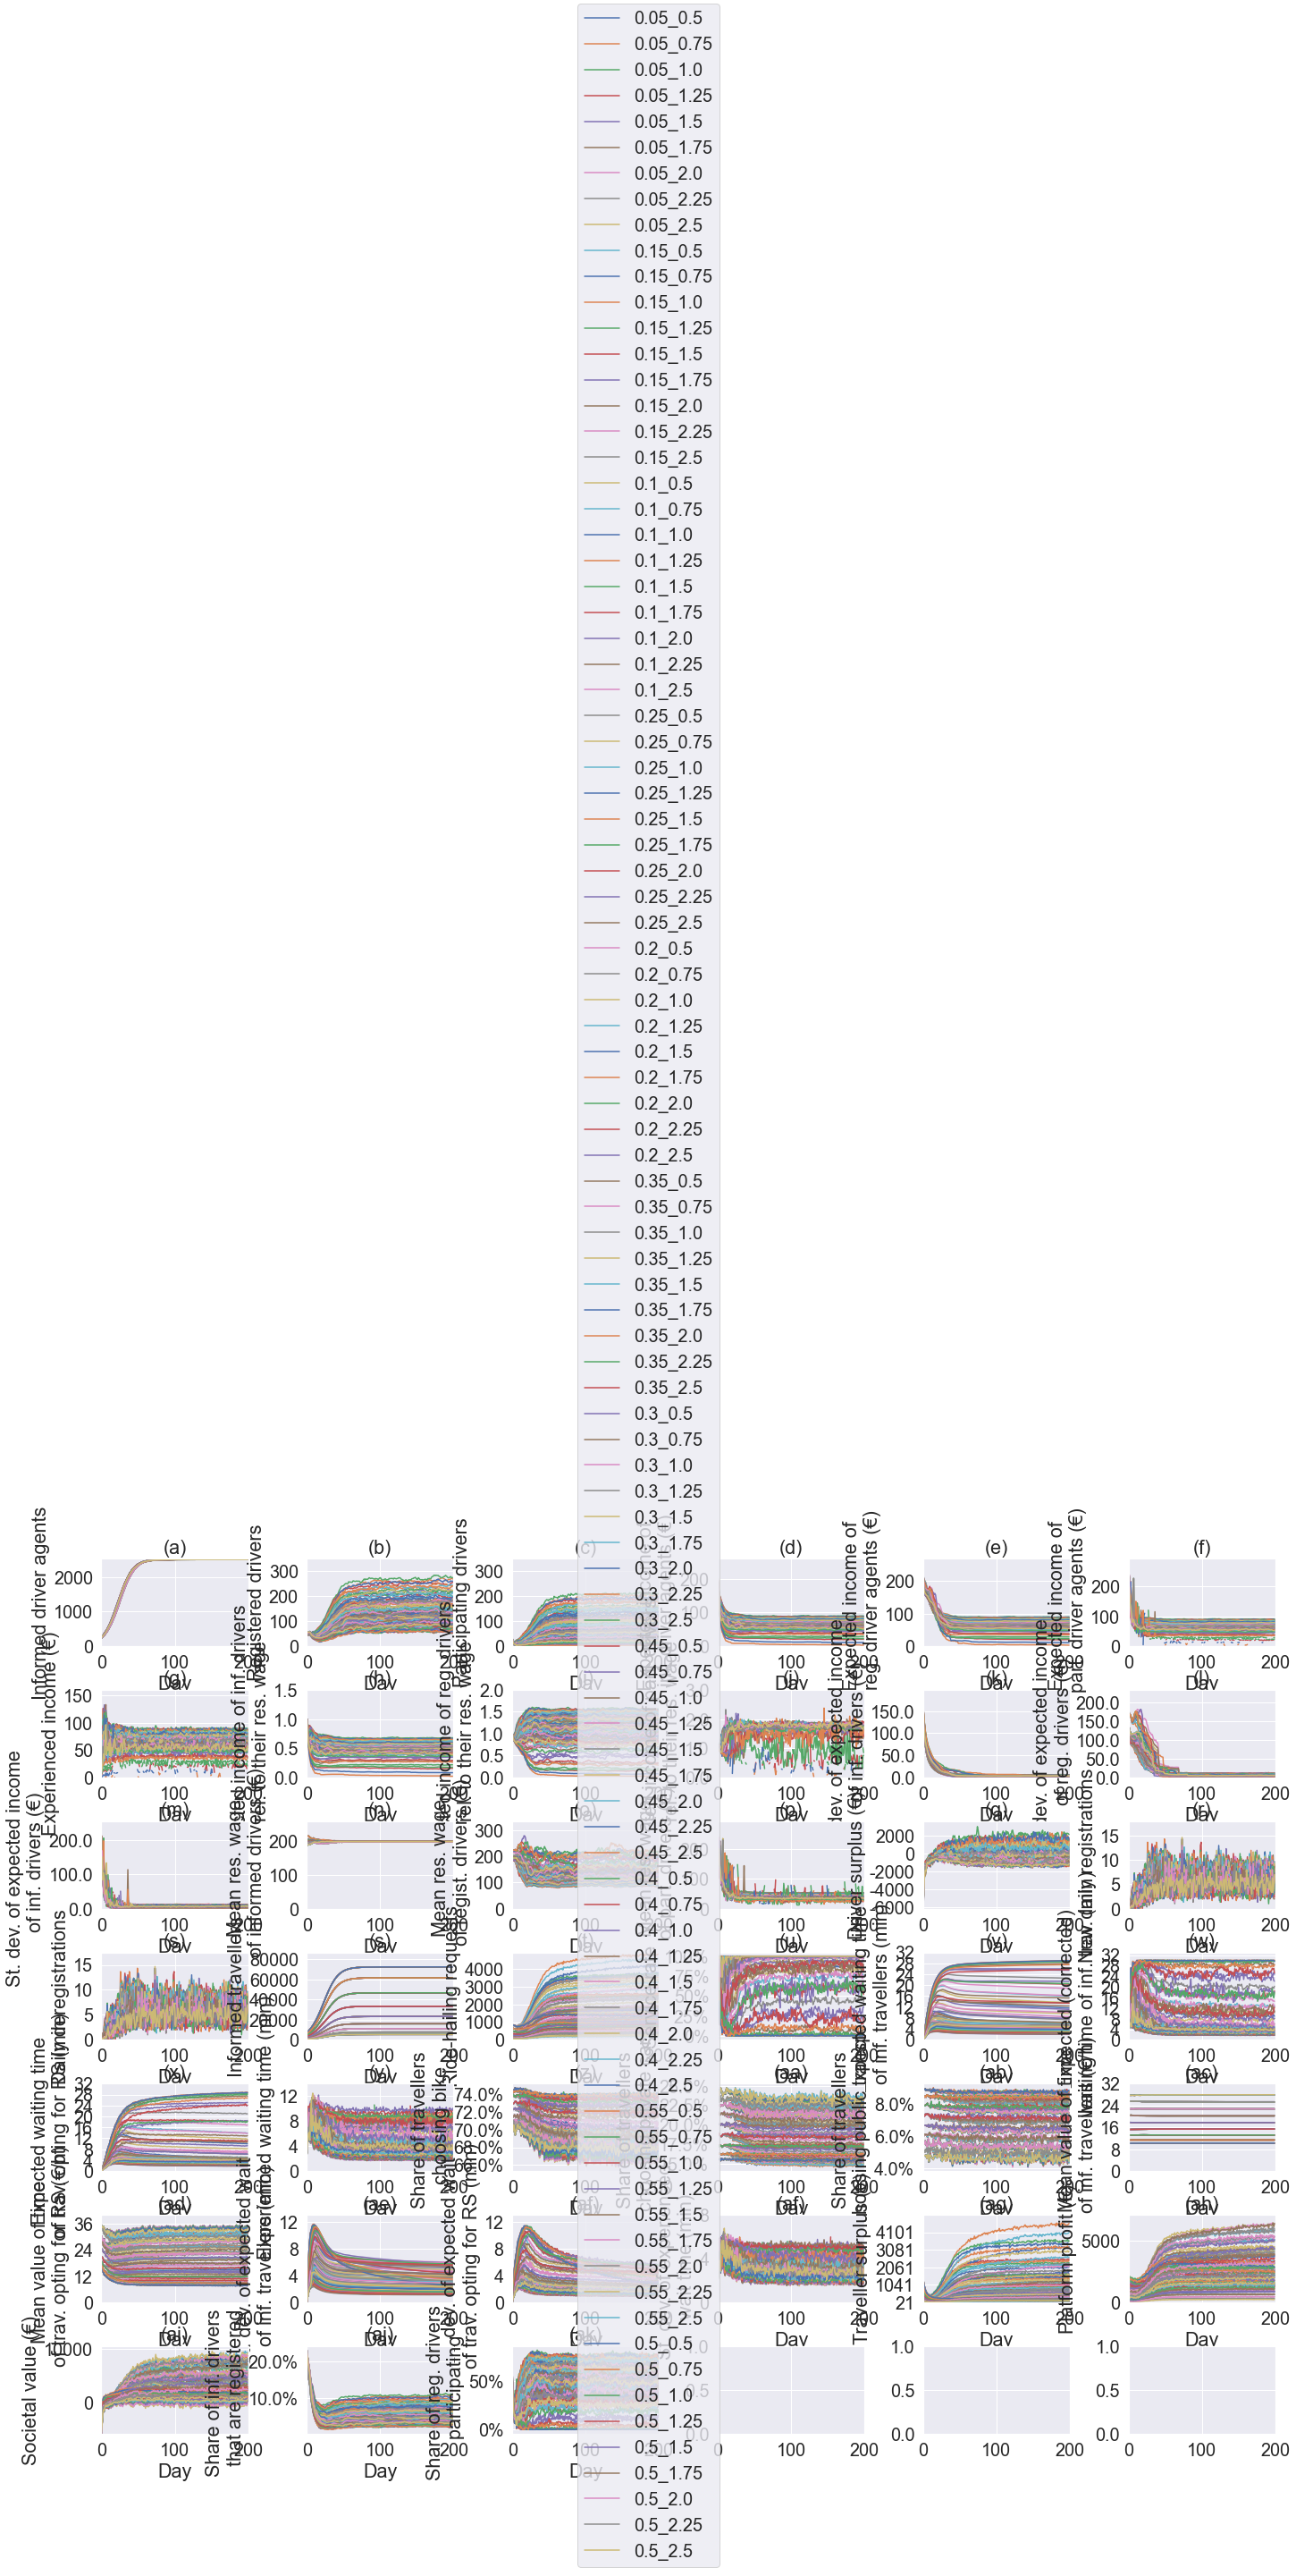

In [23]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals)
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'dynamics_multi_fig.jpg'),dpi=300,bbox_inches='tight')

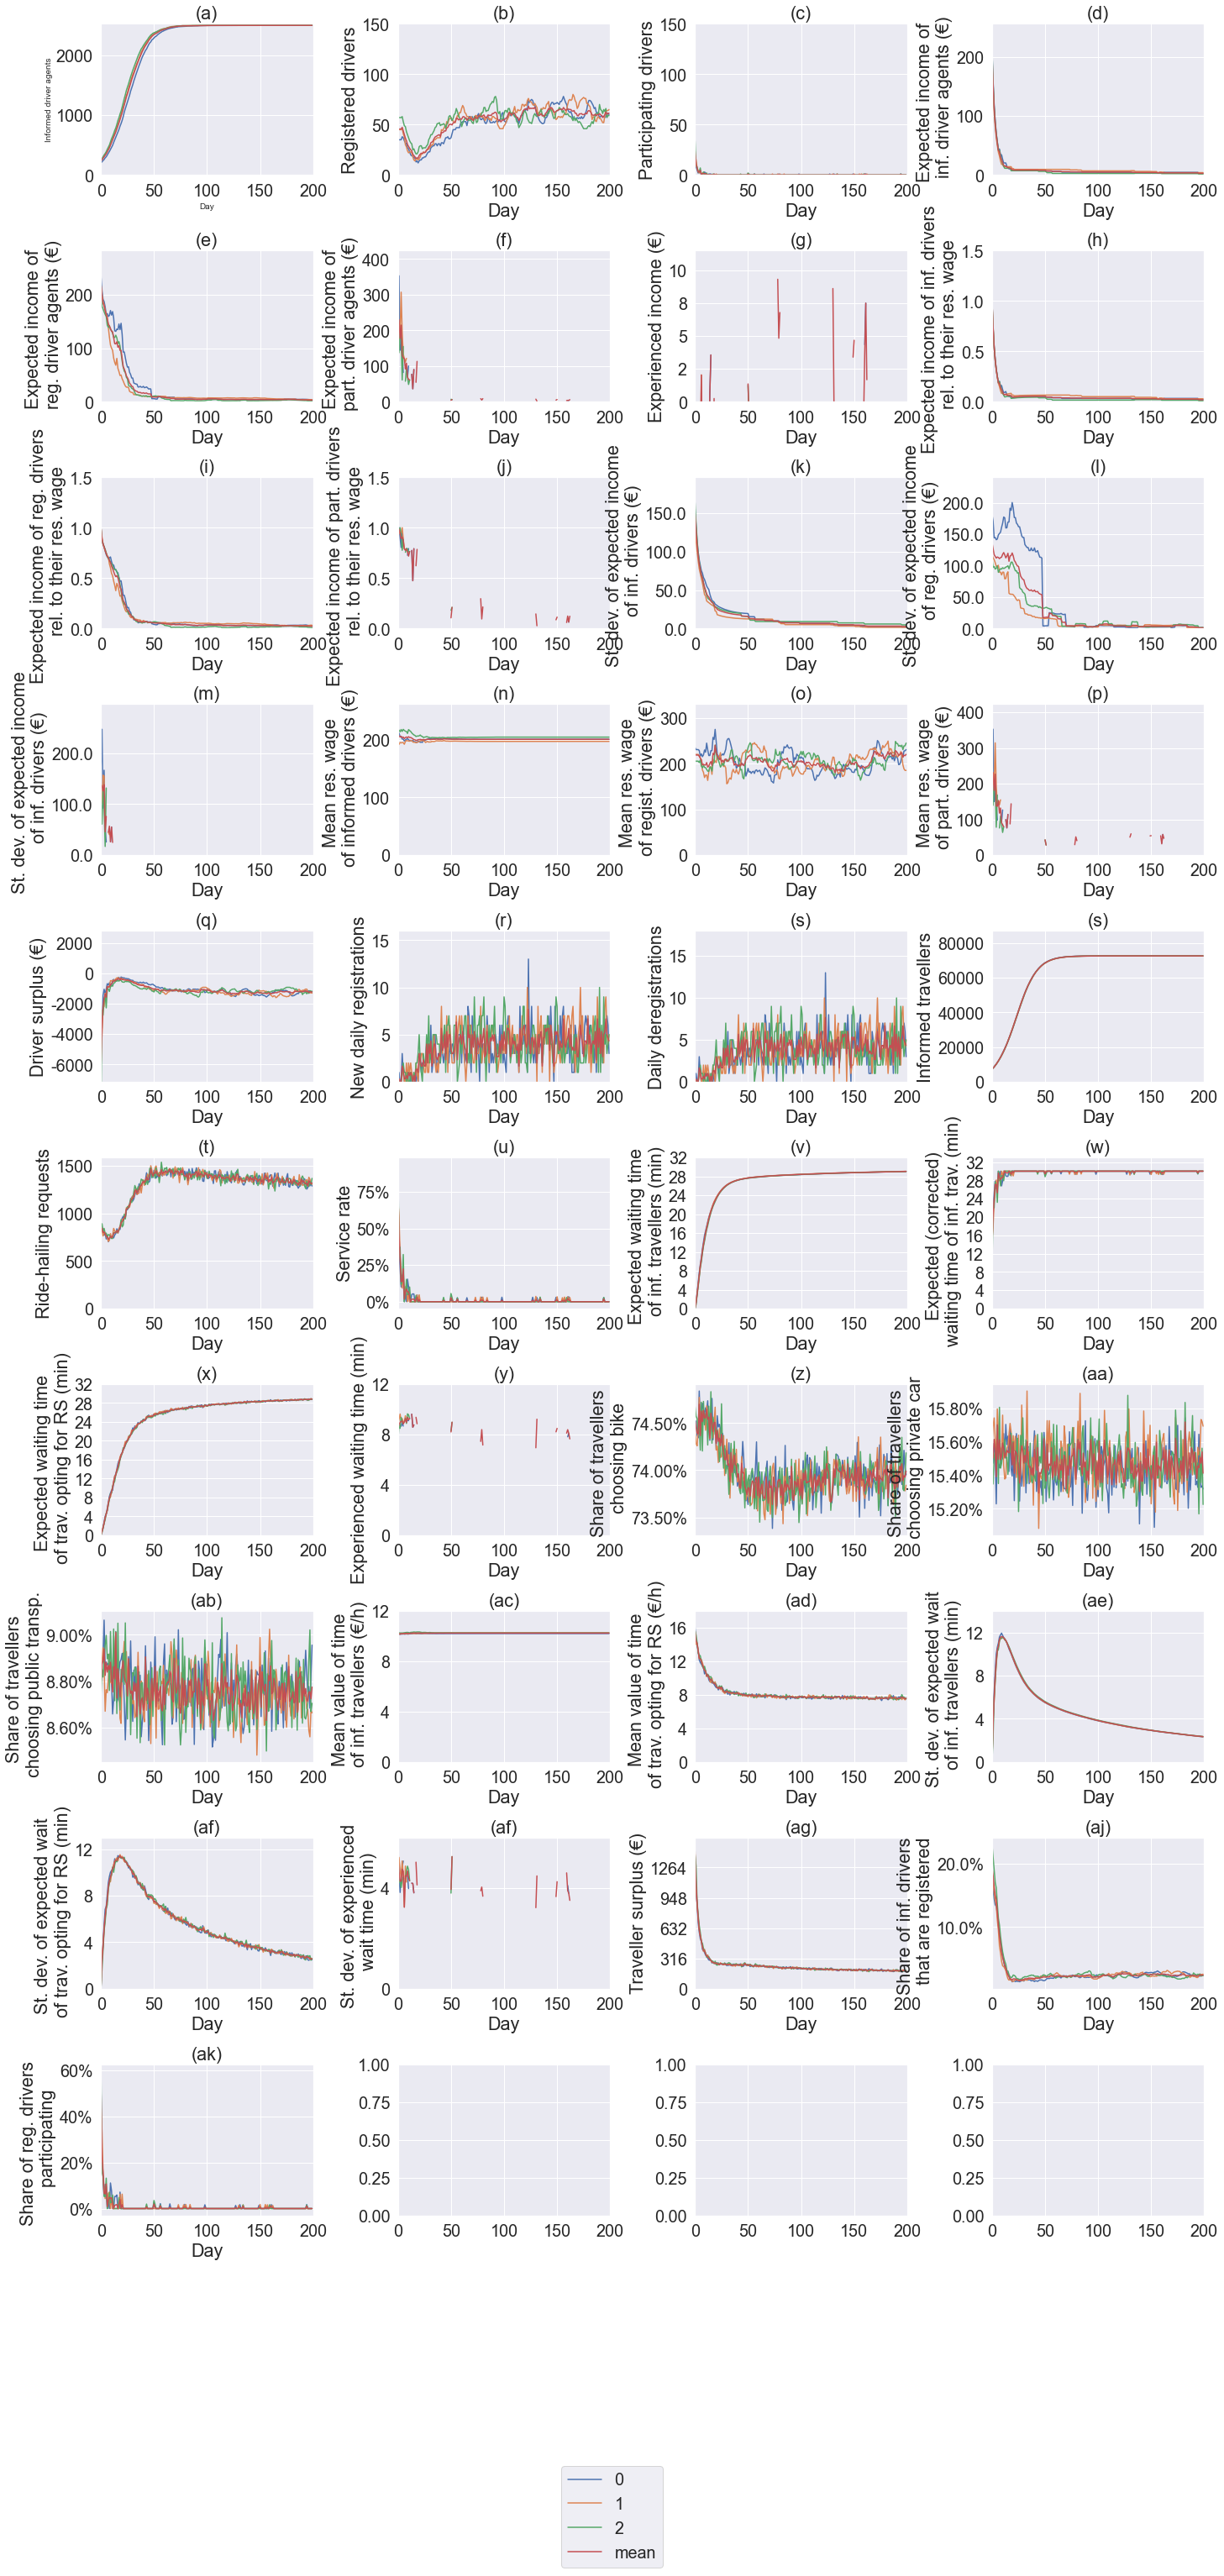

In [24]:
# Plot all runs within a single scenario - all indicators in one graph
scn_name = '0.55_0.5'
# indices = scn.index[scn['val'] == scn_name].tolist()
# indices
# res_run = res
fig = plot_multi_graph_runs(d2d.sup[scn_name], d2d.dem[scn_name])
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'run_dynamics_multi_fig.jpg'),dpi=300,bbox_inches='tight')

In [25]:
# # Plot an individual indicator
# plot_inform = res_scn.sup.inform.plot()
# plot_inform.set_ylabel("Volume of informed drivers")
# plot_inform

In [26]:
# kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
# kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
# kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
# kpi_eq.requests = round(kpi_eq.requests).astype(int)
# kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
# kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
# kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
# kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
# kpi_eq.service_rate = round(kpi_eq.service_rate,1)
# kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
# kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
# kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
# kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
# kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
# kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
# kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# # kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
# kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]

# Print equilibrium indicators as LateX table
# print(eql_scn.sup.astype('str').T.to_latex(index=True))
# print(eql_scn.dem.astype('str').T.to_latex(index=True))
# print(eql_scn.plf.astype('str').T.to_latex(index=True))

In [27]:
# Plot indicators for single scenario (e.g. base scenario)
value_1 = 0.35
value_2 = 0.5 # specific scenario
fig = plot_single_scenario(res_scn, value)
fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

NameError: name 'value' is not defined

---

In [ ]:
pd.set_option('display.max_rows', 500)
micro.dem.corr_wait_time[45][['36','37']]

In [ ]:
res.dem[45].head(500)

In [ ]:
res.sup[38].head(50)

In [ ]:
# Investigating diagonal (for determination of representative sample size)
indices = [0.02,0.04,0.06,0.08,0.1,0.12,0.16,0.2,0.25]
labels = ['15000_500','30000_1000','45000_1500','60000_2000','75000_2500','90000_3000','120000_4000','150000_5000','187500_6250']

scal_sup = eql_scn.sup.loc(axis=0)[labels]
scal_sup.index = indices
scal_dem = eql_scn.dem.loc(axis=0)[labels]
scal_dem.index = indices
scal_plf = eql_scn.plf.loc(axis=0)[labels]
scal_plf.index = indices
# eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['15000_500']
# eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['15000_500']
# eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['45000_1500']
# eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['45000_1500']
# scal_sup.particip.plot()
# scal_sup.mean_perc_inc.plot()
# scal_dem.mean_wait.plot()

fig, axes = plt.subplots(2, 4, figsize = [24,10])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.2, wspace=0.3, left=.12, right=.88)

axes[0,0] = (scal_dem.perc_wait).plot(ax = axes[0,0], label='Expected')
axes[0,0] = (scal_dem.mean_wait).plot(ax = axes[0,0], label= 'Experienced')
axes[0,0].set_ylabel('Mean waiting time (s)')
axes[0,0].set_xlabel('Sample size')
axes[0, 0].set_ylim(bottom = 0) 
axes[0,0].legend()

axes[0,1] = (scal_dem.requests / scal_dem.inform).plot(ax = axes[0,1])
axes[0,1].set_ylabel('Share of travellers choosing RS')
axes[0,1].set_xlabel('Sample size')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 1].set_ylim(bottom = 0, top = 0.1)

axes[0,2] = (scal_sup.mean_perc_inc).plot(ax = axes[0,2], label = 'Expected')
axes[0,2] = (scal_sup.mean_exp_inc).plot(ax = axes[0,2], label = 'Experienced')
axes[0,2].set_ylabel('Mean perceived income (euro)')
axes[0,2].set_xlabel('Sample size')
# axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 2].set_ylim(bottom = 0, top = 100)
axes[0,2].legend()

axes[0,3] = (scal_sup.particip / scal_sup.inform).plot(ax = axes[0,3])
axes[0,3].set_ylabel('Share of driver agents participating')
axes[0,3].set_xlabel('Sample size')
axes[0,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 3].set_ylim(bottom = 0, top = 0.1) 

axes[1,0] = (scal_plf.plat_profit / scal_dem.inform).plot(ax = axes[1,0])
axes[1,0].set_ylabel('Platform profit per traveller in population (euro)')
axes[1,0].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 0].set_ylim(bottom = 0, top =0.2) 

axes[1,1] = (scal_dem.std_perc_wait).plot(ax = axes[1,1])
axes[1,1].set_ylabel('Standard dev. of expected waiting time (s)')
axes[1,1].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 1].set_ylim(bottom = 0) 

axes[1,2] = (scal_sup.std_perc_inc).plot(ax = axes[1,2])
axes[1,2].set_ylabel('St. dev. of perceived income (euro)')
axes[1,2].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 2].set_ylim(bottom = 0, top = 10) 

appr_runtime = pd.Series(index = indices, data = [5.25, 7.5, 15, 23, 28, 30, 44, 63.5, 85])
axes[1,3] = (appr_runtime).plot(ax = axes[1,3])
axes[1,3].set_ylabel('Approximate run time for 200 days for base scenario (h)')
axes[1,3].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 3].set_ylim(bottom = 0, top = 100) 

fig.savefig(os.path.join(os.getcwd(),"plots",'sample_effect.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
kpis_dem

In [ ]:
# run_id = 0
# prefs = params[run_id]['evol']['travellers']['mode_pref']
# rs_ivt = requests[run_id].dist / params[run_id]['speeds']['ride']
# rs_fare = params[run_id]['platforms']['base_fare'] + params[run_id]['platforms']['fare'] * requests[run_id].dist / 1000
# rs_fare[rs_fare < params[run_id]['platforms']['min_fare']] = params[run_id]['platforms']['min_fare']
# beta_ivt = requests[run_id].VoT * prefs['beta_cost'] / 3600
# beta_wait = beta_ivt * prefs['wait_multip']
# U_rs = beta_ivt * rs_ivt + prefs['beta_cost'] * rs_fare + prefs['ASC_rs']
# U_wait = micro.dem.wait_time[run_id].mul(beta_wait, axis=0)
# U_wait_perc  = micro.dem.perc_wait[run_id].mul(beta_wait, axis=0)
# # U_rs = U_wait.add(U_rs, axis=0)
# U_rs = U_wait_perc.add(U_rs,axis=0)
# exp_U_rs = np.exp(U_rs)
# #         requests['U_rs'] = U_rs.copy()
# #         U_best_alt = requests[run_id][['U_pt','U_car','U_bike']].max(axis=1)
# exp_df = pd.DataFrame()
# exp_df['pt'] = np.exp(requests[run_id].U_pt)
# exp_df['car'] = np.exp(requests[run_id].U_car)
# exp_df['bike'] = np.exp(requests[run_id].U_bike)
# exp_sum_alt = exp_df.pt + exp_df.car + exp_df.bike

# exp_U_tot = exp_U_rs.add(exp_sum_alt, axis=0)
# exp_U_alts = exp_U_tot - exp_U_rs
# logsum_tot = np.log(exp_U_tot)
# logsum_alts = np.log(exp_U_alts)
# logsum_diff = logsum_tot - logsum_alts
# soc_welfare = (logsum_diff / -prefs['beta_cost']).sum(axis=0)

In [ ]:
eql_scn.soc.loc[eql_scn.soc.nP == 75000]

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', -1)
micro.dem.perc_wait[45].head(50)

In [ ]:
requests[45]

In [ ]:
eql_scn.sup.std_exp_inc / eql_scn.sup.mean_exp_inc

In [ ]:
params[0]

In [ ]:
vals

In [ ]:
vals_1

In [ ]:
vals_2

In [ ]:
var_val

In [ ]:
variable_1

In [ ]:
eql_scn.sup

In [ ]:
res.dem[99]

In [ ]:
res_scn.plf

In [ ]:
scn

In [ ]:
d2d.sup['0.05_0.5']

In [ ]:
list(d2d.sup['0.55_0.5'].inform.columns)

In [ ]:
vals

In [ ]:
abc = d2d.sup['0.55_0.5'].to_Dict()
abc

In [ ]:
a = 0
for i in range(0,len(res.sup)):
    one_ptcp = (res.sup[i].particip == 1)
    if one_ptcp.any():
        print('run_id {} has day with 1 participant - scenario {}'.format(i,scn.val[i]))
        a += 1
#     if res.sup[i][res.sup[i].particip == 1].shape[0] > 0:
#         print('run_id {} has one day with 1 participant'.format(i))